# Matched Filtering Utility
Matched filtering is a core technique in sonar (and radar) for detecting a known waveform in noisy signals.

---

## 1. Theory

**Matched filtering** maximizes SNR by correlating the received signal with a time-reversed version of the transmitted pulse.

- Used to detect echoes and measure target range in sonar.
- Classic for pulse compression with linear chirps, but works for any known pulse.

---


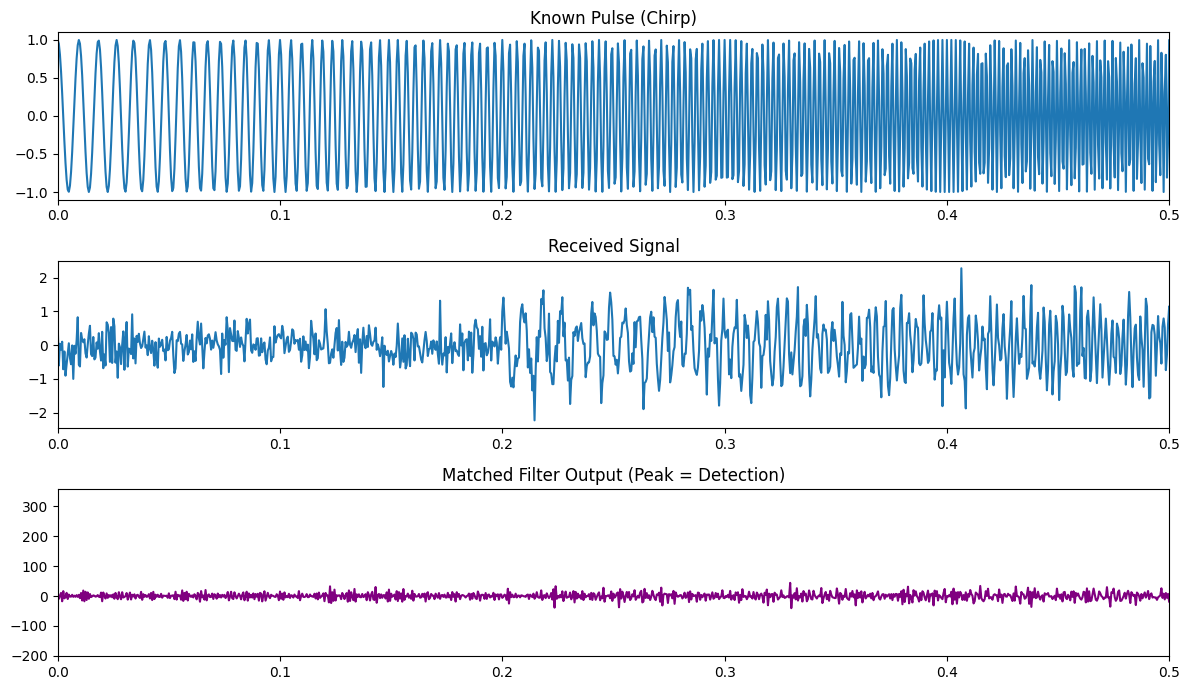

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import chirp, fftconvolve

def matched_filter(received, template):
    """Matched filter (cross-correlation with time-reversed template)."""
    return fftconvolve(received, template[::-1], mode='same')

# Simulate a sonar pulse (chirp) and echo in noise
fs = 2000
t = np.arange(0, 1.0, 1/fs)
ping = chirp(t, f0=100, f1=400, t1=0.3, method='linear')
signal = np.zeros_like(t)
signal[400:400+len(ping)//3] += ping[:len(ping)//3]  # Echo at t ~0.2s
signal += 0.4 * np.random.randn(len(t))

# Run matched filter
mf_output = matched_filter(signal, ping)

# Plot
plt.figure(figsize=(12,7))
plt.subplot(3,1,1)
plt.plot(t, ping)
plt.title('Known Pulse (Chirp)')
plt.xlim(0, 0.5)

plt.subplot(3,1,2)
plt.plot(t, signal, label='Received Signal (with echo + noise)')
plt.title('Received Signal')
plt.xlim(0, 0.5)

plt.subplot(3,1,3)
plt.plot(t, mf_output, color='purple')
plt.title('Matched Filter Output (Peak = Detection)')
plt.xlim(0, 0.5)
plt.tight_layout()
plt.show()


## Notes
- In real sonar, the template is the actual transmitted pulse.
- Use the peak index in the matched filter output to estimate time-of-arrival (and thus range to target).

**This approach can be adapted for image templates, longer recordings, or for any other DSP application where you want to detect a specific waveform in noise.**
